# Shark Attack Dataset Cleaning and Preparation

The goal of this project is to clean and prepare the shark attack dataset so it can be used for a consistent exploratory analysis.

Because the original dataset spans a very long historical period and contains many inconsistencies, we decided to focus the study on the last 40 years of available records, from 1986 onwards. This makes the analysis more relevant, comparable and reliable.

The notebook is structured as follows:
1. Initial inspection of the raw dataset
2. General structural cleaning
3. Temporal filtering and date-related cleaning
4. Variable-specific cleaning
5. Final dataset preparation

In [62]:

from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
from numpy import size

uploaded = files.upload()
uploaded.keys()

Saving GSAF5.xls to GSAF5 (1).xls


dict_keys(['GSAF5 (1).xls'])

In [63]:
!pip install xlrd
import pandas as pd

In [64]:
shark_dataset = pd.read_excel("GSAF5.xls", engine="xlrd")
display(shark_dataset.head())
shark_dataset.info()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,18th March,2026.0,Unprovoked,USA,California,Big River Beach Mendocino County,Surfing,Unknown,M,39,...,Great White Shark,US Sun: Mendocino Coast News:Melissa Michaelson:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,14th March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Swimming,Unknown,F,?,...,Unknown shark 5ft (1.5m),People Magazine: Kevin McMurray Trackingsharks...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10th March,2026.0,Unprovoked,Australia,Western Australia,Exmouth,Wing Foiling,Dave Daniell,M,?,...,Great White Shark 10ft (3m),Perth Now: Kevin McMurray Trackingsharks.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5th March,2026.0,Unprovoked,Australia,Queensland,Lady Elliott Island,Snorkeling,Unknown,M,50's,...,Unknown,News.com.au: ABC News: Andy Currie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,22nd February,2026.0,Unprovoked,New Caledonia,Noumea,Anse Vata near Point Magnin,Wing Foiling,Cyril Chevalier,M,55,...,Tiger or bull shark implicated,Johannes Marchand: Andy Currie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7082 entries, 0 to 7081
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            7082 non-null   object 
 1   Year            7080 non-null   float64
 2   Type            7064 non-null   object 
 3   Country         7032 non-null   object 
 4   State           6595 non-null   object 
 5   Location        6515 non-null   object 
 6   Activity        6499 non-null   object 
 7   Name            6864 non-null   object 
 8   Sex             6504 non-null   object 
 9   Age             4088 non-null   object 
 10  Injury          7047 non-null   object 
 11  Fatal Y/N       6521 non-null   object 
 12  Time            3555 non-null   object 
 13  Species         3951 non-null   object 
 14  Source          7062 non-null   object 
 15  pdf             6799 non-null   object 
 16  href formula    6794 non-null   object 
 17  href            6796 non-null   o

## 1. Initial inspection of the raw dataset

We start by loading the original dataset and creating a working copy. Then we inspect its structure, column names, missing values and duplicated rows in order to understand the main cleaning needs before making any transformations.



In [65]:
df_raw = shark_dataset.copy()   # Backup of the original dataset
df = df_raw.copy()              # Working dataframe

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nInfo:")
df.info()

print("\nMissing values per column:")
print(df.isna().sum().sort_values(ascending=False))

print("\nExact duplicated rows:")
print(df.duplicated().sum())

Shape: (7082, 23)

Columns:
['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity', 'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ', 'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1', 'original order', 'Unnamed: 21', 'Unnamed: 22']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7082 entries, 0 to 7081
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            7082 non-null   object 
 1   Year            7080 non-null   float64
 2   Type            7064 non-null   object 
 3   Country         7032 non-null   object 
 4   State           6595 non-null   object 
 5   Location        6515 non-null   object 
 6   Activity        6499 non-null   object 
 7   Name            6864 non-null   object 
 8   Sex             6504 non-null   object 
 9   Age             4088 non-null   object 
 10  Injury          7047 non-null   object 
 11  Fatal Y/N    

## 2. General structural cleaning

Before cleaning specific variables, we standardize the dataframe structure.

This includes:
- cleaning column names
- removing columns that are not relevant for the analysis
- renaming selected variables for easier interpretation

These changes make the dataset easier to work with and prepare it for the next cleaning steps.

In [66]:
# Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("/", "_")
)

# Drop irrelevant columns for the study
cols_to_drop = ["pdf", "href_formula", "href", "case_number", "case_number.1", "original_order", "unnamed:_21", "unnamed:_22"]
df = df.drop(columns=cols_to_drop)

# Rename column
df = df.rename(columns={"fatal_y_n": "fatal"})

print("New shape:", df.shape)
print("\nClean column names:")
print(df.columns.tolist())

print("\nColumn types:")
print(df.dtypes)

missing_summary = pd.DataFrame({
    "missing_values": df.isna().sum(),
    "missing_percentage": round(df.isna().sum() / len(df) * 100, 2)
}).sort_values(by="missing_values", ascending=False)

print("\nMissing values summary:")
print(missing_summary)

New shape: (7082, 15)

Clean column names:
['date', 'year', 'type', 'country', 'state', 'location', 'activity', 'name', 'sex', 'age', 'injury', 'fatal', 'time', 'species', 'source']

Column types:
date         object
year        float64
type         object
country      object
state        object
location     object
activity     object
name         object
sex          object
age          object
injury       object
fatal        object
time         object
species      object
source       object
dtype: object

Missing values summary:
          missing_values  missing_percentage
time                3527               49.80
species             3131               44.21
age                 2994               42.28
activity             583                8.23
sex                  578                8.16
location             567                8.01
fatal                561                7.92
state                487                6.88
name                 218                3.08
country       

## 3. Defining the temporal scope of the study

Although the original dataset contains records from a much longer time span, we decided to focus the analysis on the last 40 years, from 1986 onwards.

This decision was made for two main reasons:
- older records are less complete and less consistent
- recent incidents are more relevant for identifying current patterns and risk factors

To apply this scope properly, we first cleaned the "date" column and used it to recover missing values in "year" whenever possible. Then we created the variables "month" and "season", which will be useful later for temporal analysis.

Finally, we kept only rows with usable temporal information so the filtered dataframe is ready for the next cleaning stages.

In [67]:
print(df[df["year"].isna()][["date", "year", "type", "country", "activity", "injury"]])

# Clean the text in date
df["date_clean"] = df["date"].astype(str).str.strip().str.lower()
df["date_clean"] = df["date_clean"].str.replace(r"^reported\s+", "", regex=True)
df["date_clean"] = df["date_clean"].str.replace(r"(\d{1,2})(st|nd|rd|th)", r"\1", regex=True)

# Convert year to numeric
df["year"] = pd.to_numeric(df["year"], errors="coerce")

# Fill missing years using the year found in "date"
year_from_date = pd.to_numeric(df["date_clean"].str.extract(r"(\d{4})")[0], errors="coerce")
df["year"] = df["year"].fillna(year_from_date)

# Keep only the last 40 years
df = df[df["year"].notna() & (df["year"] >= 1986)].copy()
df["year"] = df["year"].astype(int)

# Extract month from numeric date formats like 2025-06-11, 2025.06.11 or 2025/06/11
numeric_month = pd.to_numeric(
    df["date_clean"].str.extract(r"^\d{4}[-./](\d{2})[-./]\d{2}")[0],
    errors="coerce"
)

# Extract month from written month names or abbreviations
month_patterns = {
    1: r"\bjan(?:uary)?\b",
    2: r"\bfeb(?:ruary)?\b",
    3: r"\bmar(?:ch)?\b",
    4: r"\bapr(?:il)?\b|(?<=-)ap(?=-)",
    5: r"\bmay\b",
    6: r"\bjun(?:e)?\b",
    7: r"\bjul(?:y)?\b",
    8: r"\baug(?:ust)?\b",
    9: r"\bsep(?:t(?:ember)?)?\b",
    10: r"\boct(?:ober)?\b",
    11: r"\bnov(?:ember)?\b",
    12: r"\bdec(?:ember)?\b"
}

month_from_text = pd.Series(index=df.index, dtype="float")

for month_number, pattern in month_patterns.items():
    matches = df["date_clean"].str.contains(pattern, regex=True, na=False)
    month_from_text.loc[matches] = month_number

# Combine both month extraction methods
df["month"] = numeric_month
df.loc[df["month"].isna(), "month"] = month_from_text
df["month"] = df["month"].fillna(-1).astype(int)

# Create season column
df["season"] = "Unknown"
df.loc[df["month"].isin([12, 1, 2]), "season"] = "Winter"
df.loc[df["month"].isin([3, 4, 5]), "season"] = "Spring"
df.loc[df["month"].isin([6, 7, 8]), "season"] = "Summer"
df.loc[df["month"].isin([9, 10, 11]), "season"] = "Autumn"

# Rescue season when the date text only contains a season reference
df.loc[(df["season"] == "Unknown") & (df["date_clean"].str.contains(r"\bwinter\b", na=False)), "season"] = "Winter"
df.loc[(df["season"] == "Unknown") & (df["date_clean"].str.contains(r"\bspring\b", na=False)), "season"] = "Spring"
df.loc[(df["season"] == "Unknown") & (df["date_clean"].str.contains(r"\bsummer\b", na=False)), "season"] = "Summer"
df.loc[(df["season"] == "Unknown") & (df["date_clean"].str.contains(r"\bautumn\b|\bfall\b", regex=True, na=False)), "season"] = "Autumn"

# Keep only rows with usable temporal information
df = df[(df["month"] != -1) & (df["season"] != "Unknown")].copy()

# Reset index
df = df.reset_index(drop=True)

# Checks
print("Dataset shape after temporal filtering:", df.shape)
print("\nYear range:")
print(df["year"].min(), "-", df["year"].max())

print("\nValues in month:")
print(df["month"].value_counts().sort_index())

print("\nValues in season:")
print(df["season"].value_counts())

                      date  year        type    country      activity  \
935   Reported 08-Jan-2017   NaN     Invalid  AUSTRALIA  Spearfishing   
6850  Reported 19-Aug-1836   NaN  Unprovoked    ENGLAND      Swimming   

                                      injury  
935   No attack, shark made a threat display  
6850                                   FATAL  
Dataset shape after temporal filtering: (3550, 18)

Year range:
1986 - 2026

Values in month:
month
1     265
2     208
3     245
4     290
5     272
6     329
7     450
8     354
9     356
10    312
11    235
12    234
Name: count, dtype: int64

Values in season:
season
Summer    1133
Autumn     903
Spring     807
Winter     707
Name: count, dtype: int64


## 4. Cleaning demographic and outcome variables

In this section, we clean the variables related to the victim profile and incident outcome.

The variables included are:
- "sex"
- "age"
- "age_group"
- "fatal"

The goal is to standardize inconsistent labels, replace unclear values with "Unknown" when necessary, and create cleaner categories that can be used directly in the analysis.

### 4.1 Cleaning "sex"

The "sex" column contained missing values, inconsistent capitalization and some invalid labels.

To standardize it, we grouped all values into three final categories:

- "Male"
- "Female"
- "Unknown"

This makes the variable easier to interpret and compare in the analysis stage.

In [68]:
print("Values in sex before cleaning:")
print(df["sex"].value_counts(dropna=False))

df["sex"] = df["sex"].fillna("Unknown")
df["sex"] = df["sex"].str.strip().str.upper()
df["sex"] = df["sex"].replace({"M": "MALE", "F": "FEMALE", "M X 2": "MALE"})

df.loc[df["sex"].isin(["MALE", "FEMALE"]) == False, "sex"] = "UNKNOWN"

df["sex"] = df["sex"].replace({"MALE": "Male", "FEMALE": "Female", "UNKNOWN": "Unknown"})

print("\nValues in sex after cleaning:")
print(df["sex"].value_counts(dropna=False))

Values in sex before cleaning:
sex
M      2757
F       598
NaN     183
M         5
?         2
F         2
 M        1
m         1
lli       1
Name: count, dtype: int64

Values in sex after cleaning:
sex
Male       2764
Female      600
Unknown     186
Name: count, dtype: int64


### 4.2 Cleaning "fatal"

The "fatal" column was cleaned by standardizing the original labels and grouping them into:

- "Yes"
- "No"
- "Unknown"

This avoids inconsistencies such as lowercase values, extra spaces or unclear labels, and makes the outcome variable more reliable for later comparisons.

In [69]:
print("Values in fatal before cleaning:")
print(df["fatal"].value_counts(dropna=False))

df["fatal"] = df["fatal"].fillna("Unknown")
df["fatal"] = df["fatal"].str.strip().str.upper()
df["fatal"] = df["fatal"].replace({"Y": "YES", "N": "NO", "Y X 2": "YES", "NQ": "NO"})

df.loc[df["fatal"].isin(["YES", "NO"]) == False, "fatal"] = "UNKNOWN"

df["fatal"] = df["fatal"].replace({"YES": "Yes", "NO": "No", "UNKNOWN": "Unknown"})

print("\nValues in fatal after cleaning:")
print(df["fatal"].value_counts(dropna=False))

Values in fatal before cleaning:
fatal
N          2921
Y           381
NaN         223
UNKNOWN      14
F             5
M             3
n             1
Nq            1
2017          1
Name: count, dtype: int64

Values in fatal after cleaning:
fatal
No         2923
Yes         381
Unknown     246
Name: count, dtype: int64


### 4.3 Cleaning "age" and creating "age_group"

The original "age" column contained missing values, symbols, text fragments and non-standard formats.

To clean it, we extracted the numeric age whenever possible and assigned "-1" to unknown or invalid values. Then we created the "age_group" column to classify cases into broader age ranges.

This makes the age information easier to summarize and visualize, while preserving a separate "Unknown" group for records with missing or unusable values.

In [70]:
print("Values in age before cleaning:")
print(df["age"].value_counts(dropna=False).head())

def clean_age(value):
    value = str(value).strip()

    if value == "nan" or value == "?" or value == "":
        return -1

    number = ""

    for char in value:
        if char.isdigit():
            number = number + char
        else:
            break

    if number == "":
        return -1
    else:
        return int(number)

df["age"] = df["age"].apply(clean_age)

print("\nValues in age after cleaning:")
print(df["age"].value_counts(dropna=False).head())

def age_group(age):
    if age == -1:
        return "Unknown"
    elif age < 10:
        return "0-9"
    elif age < 20:
        return "10-19"
    elif age < 30:
        return "20-29"
    elif age < 40:
        return "30-39"
    elif age < 50:
        return "40-49"
    elif age < 60:
        return "50-59"
    elif age < 70:
        return "60-69"
    elif age < 80:
        return "70-79"
    elif age < 90:
        return "80-89"
    else:
        return "90+"

df["age_group"] = df["age"].apply(age_group)

print("\nValues in age_group:")
print(df["age_group"].value_counts(dropna=False))

Values in age before cleaning:
age
NaN    887
15      55
17      46
20      46
21      44
Name: count, dtype: int64

Values in age after cleaning:
age
-1     933
 20     91
 17     89
 15     87
 16     83
Name: count, dtype: int64

Values in age_group:
age_group
Unknown    933
10-19      687
20-29      645
30-39      455
40-49      344
50-59      236
0-9        111
60-69      109
70-79       26
80-89        4
Name: count, dtype: int64


## 5. Cleaning time-related incident information

The original "time" column contained a mix of exact hours, vague expressions such as "morning" or "afternoon", and many unclear values.

Instead of trying to preserve the original raw text, we created a new variable called "time_period", which groups incidents into broader and more comparable time ranges:

- "00:00-05:59"
- "06:00-11:59"
- "12:00-17:59"
- "18:00-20:59"
- "21:00-23:59"
- "Unknown"

This approach reduces noise and makes it easier to identify time-related patterns.

In [71]:
print("Values in time before cleaning:")
print(df["time"].value_counts(dropna=False).head(30))

time_periods = []

for value in df["time"]:
    value = str(value).strip().lower()

    if value in ["nan", "?", "not stated", "unknown", "", "pm", "am"]:
        time_periods.append("Unknown")

    elif "morning" in value:
        time_periods.append("06:00-11:59")

    elif "afternoon" in value or "noon" in value:
        time_periods.append("12:00-17:59")

    elif "evening" in value:
        time_periods.append("18:00-20:59")

    elif "night" in value:
        time_periods.append("21:00-23:59")

    elif value[:2].isdigit():
        hour = int(value[:2])

        if hour < 6:
            time_periods.append("00:00-05:59")
        elif hour < 12:
            time_periods.append("06:00-11:59")
        elif hour < 18:
            time_periods.append("12:00-17:59")
        elif hour < 21:
            time_periods.append("18:00-20:59")
        else:
            time_periods.append("21:00-23:59")

    else:
        time_periods.append("Unknown")

df["time_period"] = time_periods

print("\nValues in time_period:")
print(df["time_period"].value_counts(dropna=False))

Values in time before cleaning:
time
NaN          1074
Afternoon     132
15h00          91
11h00          89
Morning        89
16h00          79
14h00          77
12h00          65
13h00          61
16h30          60
17h00          58
18h00          54
11h30          54
17h30          52
15h30          51
10h00          51
14h30          49
13h30          48
09h00          44
10h30          41
12h30          33
08h00          33
18h30          28
07h30          26
08h30          26
09h30          26
?              25
07h00          21
19h00          20
11h15          17
Name: count, dtype: int64

Values in time_period:
time_period
12:00-17:59    1261
Unknown        1186
06:00-11:59     837
18:00-20:59     210
21:00-23:59      36
00:00-05:59      20
Name: count, dtype: int64


## 6. Grouping the "activity" variable

The original "activity" column contained many very specific descriptions, spelling variations and inconsistent labels.

To make the analysis more useful, we grouped these values into broader categories such as:

- "Surfing/Boardsports"
- "Fishing"
- "Swimming"
- "Diving/Snorkeling"
- "Boating/Paddling"
- "In Water"
- "Shark interaction"
- "Other"
- "Unknown"

This grouping reduces noise in the dataset and makes it easier to compare incident patterns across different types of activity.

In [72]:
activity_groups = []

for value in df["activity"].fillna("Unknown"):
    value = str(value).strip().lower()

    if value in ["unknown", "not stated", "undisclosed", "", "?"]:
        activity_groups.append("Unknown")

    elif "shark" in value and ("feed" in value or "tag" in value or "bait" in value or "harass" in value or "free" in value or "moving captive" in value or "teas" in value or "touch" in value or "lasso" in value or "selfie" in value or "pett" in value or "wrangling" in value or "measuring" in value or "photograph" in value or "watching" in value or "rescue" in value or "tank" in value):
        activity_groups.append("Shark interaction")

    elif "fish" in value or "spearfishing" in value or "fihing" in value or "spearishing" in value or "lobster" in value or "scallop" in value or "casting a net" in value or "opihi" in value:
        activity_groups.append("Fishing")

    elif "scuba" in value or "dive" in value or "diving" in value or "freediving" in value or "free diving" in value or "snorkel" in value or "snorkelling" in value:
        activity_groups.append("Diving/Snorkeling")

    elif "surf" in value or "body board" in value or "body-board" in value or "bodyboard" in value or "boogie" in value or "boggie" in value or "body surf" in value or "foil" in value or "kite" in value or "windsurf" in value or "paddleboard" in value or "paddle boarding" in value or "surf ski" in value or "surf-ski" in value or "skimboard" in value or value == "sup" or "wakeboard" in value or "kneeboard" in value:
        activity_groups.append("Surfing/Boardsports")

    elif "kayak" in value or "kakaying" in value or "canoe" in value or "rowing" in value or "shipwreck" in value or "sea disaster" in value or "boat" in value or "sailing" in value or "jet ski" in value or "jet skiing" in value or "dinghy" in value or "adrift" in value or "expedition" in value or "paddling" in value or "fix motor" in value:
        activity_groups.append("Boating/Paddling")

    elif "swim" in value or "swimmingq" in value or "bathing" in value or "lifesaving" in value or "lifeguard" in value or "ocean training" in value:
        activity_groups.append("Swimming")

    elif "wad" in value or "walk" in value or "standing" in value or "floating" in value or "treading water" in value or "sitting" in value or "playing" in value or "jumped into the water" in value or "jumped overboard" in value or "jumping off rocks" in value or "fell into the water" in value or "fell off" in value or value == "jumping" or "jumping in the waves" in value or "kneeling in the water" in value or "squatting in the water" in value or "washing hands" in value:
        activity_groups.append("In Water")

    else:
        activity_groups.append("Other")

df["activity_group"] = activity_groups

print("Values in activity_group:")
print(df["activity_group"].value_counts(dropna=False))

print("\nTop values inside Other:")
print(df[df["activity_group"] == "Other"]["activity"].value_counts(dropna=False).head(30))

Values in activity_group:
activity_group
Surfing/Boardsports    1371
Fishing                 594
Swimming                552
Diving/Snorkeling       364
In Water                256
Unknown                 179
Boating/Paddling        119
Other                    71
Shark interaction        44
Name: count, dtype: int64

Top values inside Other:
activity
Murder                                                                    3
Filming                                                                   2
Towing a dead whale out to sea                                            1
Rescuing female companion                                                 1
Watching the sardine run                                                  1
Jumped into water                                                         1
Sightseeing                                                               1
Jackass Team's publicity stunt for Discovery Channel's Shark Week 2021    1
Body Recovery                         

### 6.1 Final refinement of grouped activities

After the first grouping pass, we reviewed the remaining values classified as "Other" and manually reassigned a small number of clearly identifiable activities.

This final refinement helps reduce unnecessary residual noise without overcomplicating the classification logic.

In [73]:
df.loc[df["activity"].str.contains("paddle-boarding", case=False, na=False), "activity_group"] = "Surfing/Boardsports"

df.loc[df["activity"].str.contains("crabbing|shrimping", case=False, regex=True, na=False), "activity_group"] = "Fishing"

df.loc[df["activity"].str.contains("air disaster|cargo ship|capsized|yacht race|sinking|tsunami|log for 24 hours|dead whale out to sea", case=False, regex=True, na=False), "activity_group"] = "Boating/Paddling"

df.loc[df["activity"].str.contains("removing hook from shark|removing shark from net|reviving a sedated shark|chase shark out to sea|dragging stranded shark|chumming", case=False, regex=True, na=False), "activity_group"] = "Shark interaction"

df.loc[df["activity"].str.contains("jumped into water|washing his feet|crawling|crouching in 2' of water|rescuing female companion|rescuing|body recovery", case=False, regex=True, na=False), "activity_group"] = "In Water"

print("Values in activity_group:")
print(df["activity_group"].value_counts(dropna=False))

print("\nTop values inside Other:")
print(df[df["activity_group"] == "Other"]["activity"].value_counts(dropna=False).head(30))

Values in activity_group:
activity_group
Surfing/Boardsports    1372
Fishing                 593
Swimming                552
Diving/Snorkeling       364
In Water                263
Unknown                 179
Boating/Paddling        132
Shark interaction        51
Other                    44
Name: count, dtype: int64

Top values inside Other:
activity
Murder                                                                    3
Filming                                                                   2
Watching the sardine run                                                  1
Sightseeing                                                               1
Jackass Team's publicity stunt for Discovery Channel's Shark Week 2021    1
Photo shoot                                                               1
Feeding stingrays?                                                        1
Accidentally stood on hooked shark's tail before attempting to gut it     1
Killing  sharks                       

## 7. Cleaning geographic variables

The original geographic information was simplified by creating two cleaner variables:

- "country_clean"
- "state_clean"

Both columns were standardized by:
- removing extra spaces
- normalizing punctuation
- converting text to uppercase
- replacing missing values with "UNKNOWN"
- correcting a small number of obvious inconsistencies and typos

We also created a helper variable, "region_clean", which uses "state_clean" when available and falls back to "country_clean" otherwise. This is useful for broader summaries, although the main analysis should rely on "country_clean" and "state_clean" separately.

In [74]:
# Create clean country and state columns
df["country_clean"] = df["country"].fillna("Unknown").str.strip().str.upper()
df["state_clean"] = df["state"].fillna("Unknown").str.strip().str.upper()

# Basic regex cleaning
df["country_clean"] = df["country_clean"].str.replace(r"\s+", " ", regex=True).str.replace(r"\.", "", regex=True).str.replace(r"\s*&\s*", " AND ", regex=True)
df["state_clean"] = df["state_clean"].str.replace(r"\s+", " ", regex=True).str.replace(r"\.", "", regex=True).str.replace(r"\s*&\s*", " AND ", regex=True)

# Normalize country names
df["country_clean"] = df["country_clean"].str.replace(r"^TURKS\s+AND\s+CAICOS.*$", "TURKS AND CAICOS", regex=True)
df["country_clean"] = df["country_clean"].str.replace(r"^REUNION.*$", "REUNION", regex=True)
df["country_clean"] = df["country_clean"].str.replace(r"^ST\s+MARTIN$", "ST MARTIN", regex=True)
df["country_clean"] = df["country_clean"].str.replace(r"^TRINIDAD.*TOBAGO$", "TRINIDAD AND TOBAGO", regex=True)
df["country_clean"] = df["country_clean"].str.replace(r"^MALDIVE.*$", "MALDIVES", regex=True)

df["country_clean"] = df["country_clean"].replace({
    "COLUMBIA": "COLOMBIA",
    "ENGLAND": "UNITED KINGDOM",
    "SCOTLAND": "UNITED KINGDOM",
    "BRITISH OVERSEAS TERRITORY": "UNITED KINGDOM",
    "ST HELENA, BRITISH OVERSEAS TERRITORY": "UNITED KINGDOM",
    "HAWAII": "USA",
    "CANARY ISLANDS": "SPAIN",
    "ATLANTIC OCEAN": "OPEN WATER",
    "CORAL SEA": "OPEN WATER",
    "?": "UNKNOWN",
    "NAN": "UNKNOWN",
    "": "UNKNOWN"
})

# Normalize state names
df["state_clean"] = df["state_clean"].replace({
    "?": "UNKNOWN",
    "NAN": "UNKNOWN",
    "NONE": "UNKNOWN",
    "": "UNKNOWN"
})

df["state_clean"] = df["state_clean"].str.replace(r"^NSW$", "NEW SOUTH WALES", regex=True)
df["state_clean"] = df["state_clean"].str.replace(r"^WA$", "WESTERN AUSTRALIA", regex=True)
df["state_clean"] = df["state_clean"].str.replace(r"^WESTERM AUSTRALIA$", "WESTERN AUSTRALIA", regex=True)
df["state_clean"] = df["state_clean"].str.replace(r"^NEW\s+SOUTH\s+WALES$", "NEW SOUTH WALES", regex=True)
df["state_clean"] = df["state_clean"].str.replace(r"^INHAMBE PROVINCE$", "INHAMBANE PROVINCE", regex=True)
df["state_clean"] = df["state_clean"].str.replace(r"^EASTEN CAPE PROVINCE$", "EASTERN CAPE PROVINCE", regex=True)
df["state_clean"] = df["state_clean"].str.replace(r"^FLORIA$", "FLORIDA", regex=True)
df["state_clean"] = df["state_clean"].str.replace(r"^QUNTANA ROO$", "QUINTANA ROO", regex=True)
df["state_clean"] = df["state_clean"].str.replace(r"^SOUTH SINAI$", "SOUTH SINAI PENINSULA", regex=True)
df["state_clean"] = df["state_clean"].str.replace(r"^GRAND\s+BAHAMA\s+ISLAND$", "GRAND BAHAMA ISLAND", regex=True)

# Final checks
print("Missing values in country_clean:")
print((df["country_clean"] == "UNKNOWN").sum())

print("\nMissing values in state_clean:")
print((df["state_clean"] == "UNKNOWN").sum())

print("\nTop country_clean values:")
print(df["country_clean"].value_counts(dropna=False).head(30))

print("\nTop state_clean values:")
print(df["state_clean"].value_counts(dropna=False).head(30))

print("\nTotal number of registers with known country:")
print((df["country_clean"] != "UNKNOWN").sum())

Missing values in country_clean:
2

Missing values in state_clean:
149

Top country_clean values:
country_clean
USA                 1697
AUSTRALIA            676
SOUTH AFRICA         250
BRAZIL               109
BAHAMAS              106
NEW ZEALAND           68
REUNION               55
NEW CALEDONIA         50
MEXICO                45
EGYPT                 36
FRENCH POLYNESIA      31
FIJI                  24
SPAIN                 23
JAPAN                 20
UNITED KINGDOM        19
MOZAMBIQUE            14
PAPUA NEW GUINEA      14
PHILIPPINES           14
TONGA                 11
ITALY                 11
THAILAND              11
VIETNAM               10
COSTA RICA            10
INDONESIA              9
CUBA                   9
ECUADOR                9
HONG KONG              9
TURKS AND CAICOS       8
JAMAICA                8
MALDIVES               8
Name: count, dtype: int64

Top state_clean values:
state_clean
FLORIDA                  876
NEW SOUTH WALES          232
HAWAII           

## 8. Cleaning and filtering the "type" variable

The "type" column was reviewed to keep only records that represent valid and usable shark-related incidents for the analysis.

After standardizing the text values, we kept the following categories:

- "Unprovoked"
- "Provoked"
- "Watercraft"
- "Sea Disaster"

Records labeled as "Invalid", "Questionable", "Unconfirmed", "Unverified", "Under investigation", missing values or vague labels such as "?" were excluded, since they could distort the final analysis.

In [75]:
print("Missing values in type:")
print(df["type"].isna().sum())

print("\nValues in type:")
print(df["type"].value_counts(dropna=False))

# Clean type values
df["type_clean"] = df["type"].fillna("Unknown").str.strip().str.title()

df["type_clean"] = df["type_clean"].replace({
    "Unprovoked": "Unprovoked",
    "Provoked": "Provoked",
    "Watercraft": "Watercraft",
    "Sea Disaster": "Sea Disaster",
    "Invalid": "Invalid",
    "Questionable": "Questionable",
    "Unconfirmed": "Unconfirmed",
    "Unverified": "Unverified",
    "Under Investigation": "Under Investigation",
    "?": "Unknown",
    "Unknown": "Unknown"
})

# Keep only valid incident types
valid_types = ["Unprovoked", "Provoked", "Watercraft", "Sea Disaster"]
df = df[df["type_clean"].isin(valid_types)].copy()

# Reset index after filtering
df = df.reset_index(drop=True)

# Final checks
print("Values in type_clean:")
print(df["type_clean"].value_counts(dropna=False))

print("\nFinal dataset shape after type cleaning:")
print(df.shape)

Missing values in type:
14

Values in type:
type
Unprovoked             2838
Provoked                262
Invalid                 223
Watercraft              152
Sea Disaster             28
Questionable             26
NaN                      14
 Provoked                 2
unprovoked                1
?                         1
Unconfirmed               1
Unverified                1
Under investigation       1
Name: count, dtype: int64
Values in type_clean:
type_clean
Unprovoked      2839
Provoked         264
Watercraft       152
Sea Disaster      28
Name: count, dtype: int64

Final dataset shape after type cleaning:
(3283, 24)


## 9. Cleaning and filtering the "injury" variable


In [76]:
# injury column having just .27% nulls, so droping those rows
df = df.dropna(subset=['injury'])

## 10. Final analysis-ready dataset

At this stage, the dataset has been filtered and cleaned enough to support the main questions of the project.

To keep the final dataframe clear and focused, we preserve only the variables that are directly relevant for the analysis:

- "year"
- "month"
- "season"
- "time_period"
- "country_clean"
- "state_clean"
- "activity_group"
- "sex"
- "age"
- "age_group"
- "fatal"
- "type_clean"
- "injury"

This final version of the dataframe is ready to be used for visual analysis and pattern exploration.

In [77]:
# Drop helper column used during temporal cleaning
df = df.drop(columns=["date_clean"])

# Final version with all relevant variables
final_columns = [
    "year",
    "month",
    "season",
    "time_period",
    "country_clean",
    "state_clean",
    "activity_group",
    "sex",
    "age",
    "age_group",
    "fatal",
    "type_clean",
    "injury"
]

df_final = df[final_columns].copy()

# Reduced optional final version for the analysis
final_columns_2 = [
    "year",
    "month",
    "season",
    "time_period",
    "country_clean",
    "state_clean",
    "activity_group",
    "sex",
    "age_group",
    "fatal",
    "type_clean"
]

df_reduced = df_final[final_columns_2].copy()

print("Final dataset shape:", df_final.shape)
print("\nFinal dataset columns:")
print(df_final.columns.tolist())

print("\nReduced dataset shape:", df_reduced.shape)
print("\nReduced dataset columns:")
print(df_reduced.columns.tolist())

display(df_final.head(20))
print("\n")
display(df_reduced.head(20))

Final dataset shape: (3274, 13)

Final dataset columns:
['year', 'month', 'season', 'time_period', 'country_clean', 'state_clean', 'activity_group', 'sex', 'age', 'age_group', 'fatal', 'type_clean', 'injury']

Reduced dataset shape: (3274, 11)

Reduced dataset columns:
['year', 'month', 'season', 'time_period', 'country_clean', 'state_clean', 'activity_group', 'sex', 'age_group', 'fatal', 'type_clean']


,year,month,season,time_period,country_clean,state_clean,activity_group,sex,age,age_group,fatal,type_clean,injury
0,2026,3,Spring,12:00-17:59,USA,CALIFORNIA,Surfing/Boardsports,Male,39,30-39,No,Unprovoked,Injuries to both legs and feet
1,2026,3,Spring,06:00-11:59,AUSTRALIA,WESTERN AUSTRALIA,Swimming,Female,-1,Unknown,No,Unprovoked,Minor injuries
2,2026,3,Spring,06:00-11:59,AUSTRALIA,WESTERN AUSTRALIA,Surfing/Boardsports,Male,-1,Unknown,No,Unprovoked,None reported damage to board
3,2026,3,Spring,06:00-11:59,AUSTRALIA,QUEENSLAND,Diving/Snorkeling,Male,50,50-59,No,Unprovoked,Lacerations elbow and abdomen
4,2026,2,Winter,Unknown,NEW CALEDONIA,NOUMEA,Surfing/Boardsports,Male,55,50-59,Yes,Unprovoked,Deep wounds arms and legs
5,2026,2,Winter,Unknown,CAYMAN ISLANDS,LITTLE CAYMAN ISLAND,Diving/Snorkeling,Male,-1,Unknown,No,Unprovoked,Minor puncture wounds to thigh
6,2026,1,Winter,Unknown,BRAZIL,RECIFE,Swimming,Male,13,10-19,Yes,Unprovoked,Right thigh and lower leg stripped of flesh
7,2026,1,Winter,06:00-11:59,AUSTRALIA,NEW SOUTH WALES,Surfing/Boardsports,Male,-1,Unknown,No,Unprovoked,No injury shark knocked man of his board
8,2026,1,Winter,18:00-20:59,AUSTRALIA,TASMANIA,Swimming,Female,-1,Unknown,No,Unprovoked,Puncture wounds to right knee
9,2026,1,Winter,06:00-11:59,AUSTRALIA,NEW SOUTH WALES,Surfing/Boardsports,Male,39,30-39,No,Unprovoked,Minor cuts and abrasions


,year,month,season,time_period,country_clean,state_clean,activity_group,sex,age_group,fatal,type_clean
0,2026,3,Spring,12:00-17:59,USA,CALIFORNIA,Surfing/Boardsports,Male,30-39,No,Unprovoked
1,2026,3,Spring,06:00-11:59,AUSTRALIA,WESTERN AUSTRALIA,Swimming,Female,Unknown,No,Unprovoked
2,2026,3,Spring,06:00-11:59,AUSTRALIA,WESTERN AUSTRALIA,Surfing/Boardsports,Male,Unknown,No,Unprovoked
3,2026,3,Spring,06:00-11:59,AUSTRALIA,QUEENSLAND,Diving/Snorkeling,Male,50-59,No,Unprovoked
4,2026,2,Winter,Unknown,NEW CALEDONIA,NOUMEA,Surfing/Boardsports,Male,50-59,Yes,Unprovoked
5,2026,2,Winter,Unknown,CAYMAN ISLANDS,LITTLE CAYMAN ISLAND,Diving/Snorkeling,Male,Unknown,No,Unprovoked
6,2026,1,Winter,Unknown,BRAZIL,RECIFE,Swimming,Male,10-19,Yes,Unprovoked
7,2026,1,Winter,06:00-11:59,AUSTRALIA,NEW SOUTH WALES,Surfing/Boardsports,Male,Unknown,No,Unprovoked
8,2026,1,Winter,18:00-20:59,AUSTRALIA,TASMANIA,Swimming,Female,Unknown,No,Unprovoked
9,2026,1,Winter,06:00-11:59,AUSTRALIA,NEW SOUTH WALES,Surfing/Boardsports,Male,30-39,No,Unprovoked


## Save your cleaned dataset into pickle file

In [78]:
import pickle

# assuming your cleaned dataset is called df_clean
with open("df_final.pkl", "wb") as f:
    pickle.dump(df_final, f)

In [79]:
#loading data back from pickle
df_final = pd.read_pickle("df_final.pkl")


In [80]:
missing_summary = pd.DataFrame({
    "missing_values": df_final.isna().sum(),
    "missing_percentage": round(df_final.isna().sum() / len(df) * 100, 2)
}).sort_values(by="missing_values", ascending=False)

print("\nMissing values summary:")
print(missing_summary)


Missing values summary:
                missing_values  missing_percentage
year                         0                 0.0
month                        0                 0.0
season                       0                 0.0
time_period                  0                 0.0
country_clean                0                 0.0
state_clean                  0                 0.0
activity_group               0                 0.0
sex                          0                 0.0
age                          0                 0.0
age_group                    0                 0.0
fatal                        0                 0.0
type_clean                   0                 0.0
injury                       0                 0.0


In [81]:
df_final.shape

(3274, 13)

In [82]:
countries_of_interest = ["USA", "AUSTRALIA","SOUTH AFRICA"]
df_final = df_final[df_final["country_clean"].isin(countries_of_interest)].reset_index(drop=True)
df_final.shape


(2432, 13)

In [83]:
df_final.describe()

,year,month,age
count,2432.000000,2432.000000,2432.000000
mean,2008.481497,6.784128,22.532072
std,10.261797,3.122592,18.603900
min,1986.000000,1.000000,-1.000000
25%,2001.000000,4.000000,9.000000
50%,2010.000000,7.000000,20.000000
75%,2017.000000,9.000000,35.000000
max,2026.000000,12.000000,86.000000



## Buisness Question 1

Which locations (countries, states) have the highest frequency of shark attacks?
- Attack frequency by location

Top 10 attacks by State:
state_clean
FLORIDA                  836
HAWAII                   212
NEW SOUTH WALES          211
CALIFORNIA               179
WESTERN AUSTRALIA        157
QUEENSLAND               126
SOUTH CAROLINA            98
EASTERN CAPE PROVINCE     90
WESTERN CAPE PROVINCE     84
NORTH CAROLINA            81
dtype: int64


/tmp/ipykernel_19959/4120479498.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="State", y="Number of Attacks", data=attacks_region_df, palette="Reds_r")


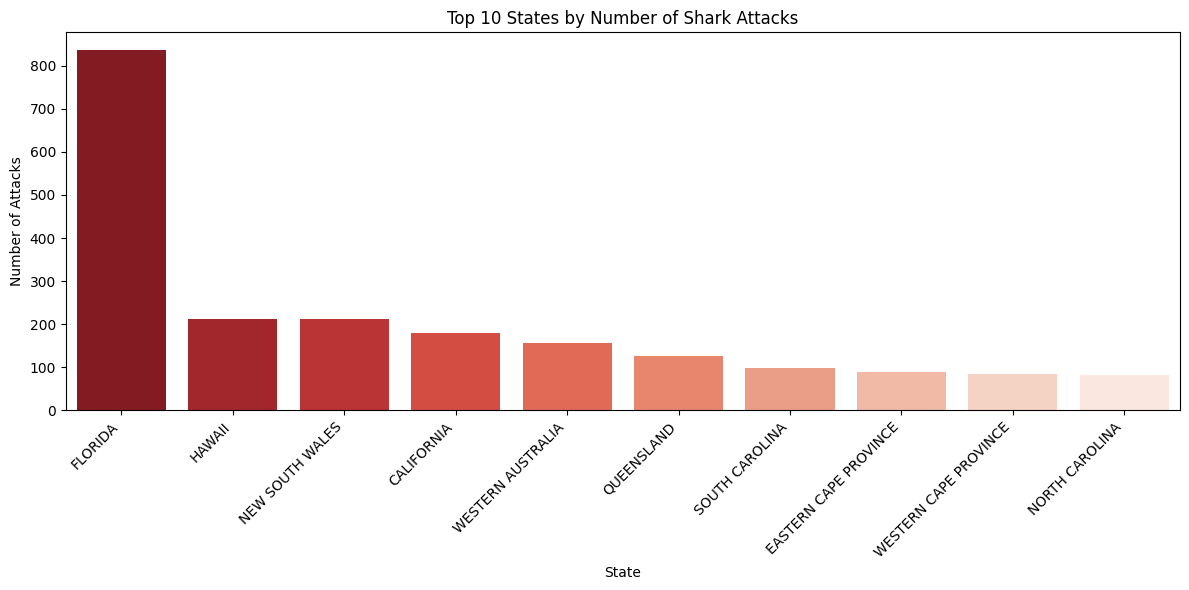

In [84]:
# Group by state and count attacks
attacks_by_region = df_final.groupby("state_clean").size().sort_values(ascending=False).head(10)

# Display table
print("Top 10 attacks by State:\n", attacks_by_region, sep="")

# Convert to DataFrame for plotting
attacks_region_df = attacks_by_region.reset_index(name="Number of Attacks")
attacks_region_df = attacks_region_df.rename(columns={"state_clean": "State"})

# Bar chart
plt.figure(figsize=(12,6))
sns.barplot(x="State", y="Number of Attacks", data=attacks_region_df, palette="Reds_r")
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 States by Number of Shark Attacks")
plt.ylabel("Number of Attacks")
plt.xlabel("State")
plt.tight_layout()
plt.show()


Frequency of Attacks by Country:

        Country  Number of Attacks
0           USA               1589
1     AUSTRALIA                615
2  SOUTH AFRICA                228


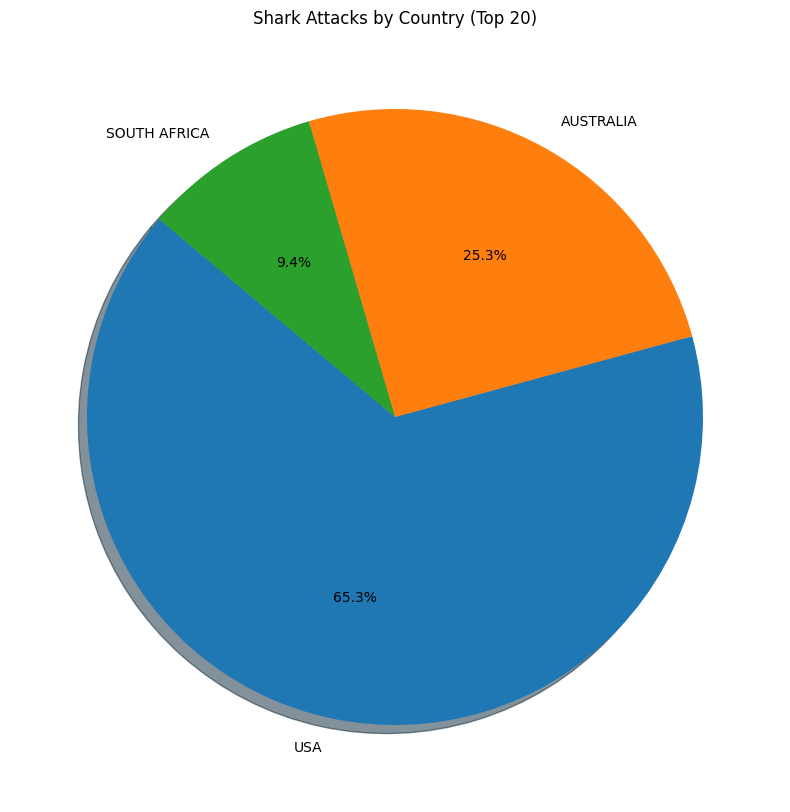

In [85]:


# Assuming df_final is already your cleaned DataFrame
# Group by country and count incidents
attacks_by_country = df_final.groupby("country_clean").size().sort_values(ascending=False).head(20)

# Convert to DataFrame for clarity
attacks_df = attacks_by_country.reset_index(name="Number of Attacks")
attacks_df = attacks_df.rename(columns={"country_clean": "Country"})

# Display table
print("Frequency of Attacks by Country:\n")
print(attacks_df)

# Plot pie chart
plt.figure(figsize=(10,10))
plt.pie(attacks_df["Number of Attacks"],
        labels=attacks_df["Country"],
        autopct="%1.1f%%",
        startangle=140,
        shadow=True)
plt.title("Shark Attacks by Country (Top 20)")
plt.show()


## Buisness Question 2

 - What time of day are shark attacks most likely to occur?
 - Seasonal trend
 - Attacks by time of day


The Most Attacks Occured During :

season
Summer    795
Autumn    674
Spring    534
Winter    429
dtype: int64


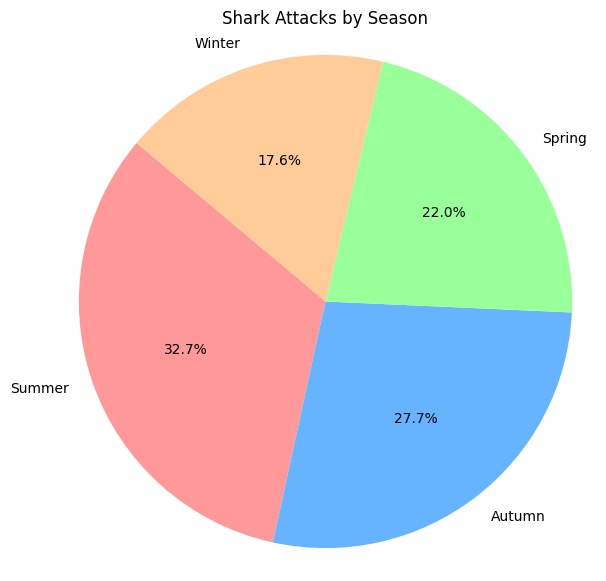

In [86]:
#attacks_by_season
attacks_by_season = df_final.groupby("season").size().sort_values(ascending=False)
print(f"The Most Attacks Occured During :\n\n{attacks_by_season}")

# Pie chart
plt.figure(figsize=(7,7))
plt.pie(attacks_by_season.values,
        labels=attacks_by_season.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
plt.title("Shark Attacks by Season")
plt.axis('equal')  # Equal aspect ratio ensures pie is circular
plt.show()

The Most Attacks Occured During :

time_labels
afternoon    1011
morning       661
Unknown       578
evening       147
night          22
midnight       13
dtype: int64


/tmp/ipykernel_19959/3687182777.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=attacks_by_time_filtered.index, y=attacks_by_time_filtered.values, palette="Reds_r")


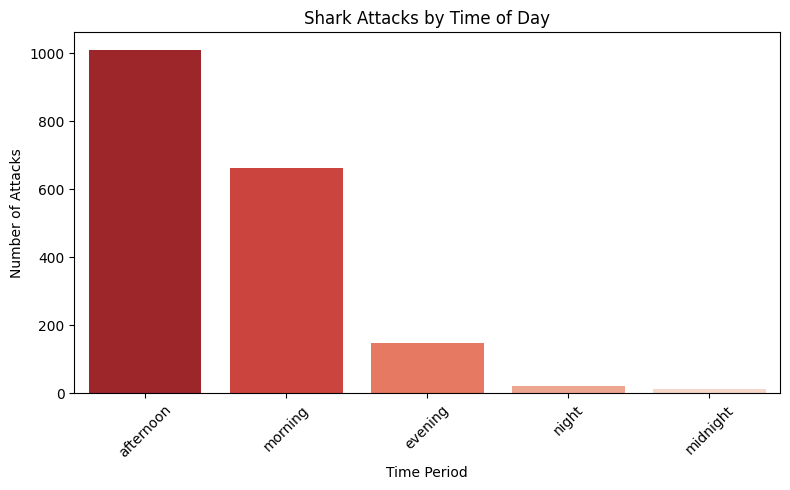

In [87]:

# Time risk
time_labels = {
    "00:00-05:59": "midnight",
    "06:00-11:59": "morning",
    "12:00-17:59": "afternoon",
    "18:00-20:59": "evening",
    "21:00-23:59": "night",
    "Unknown":"Unknown"
}

df_final["time_labels"] = df_final["time_period"].map(time_labels)
attacks_by_time = df_final.groupby("time_labels").size().sort_values(ascending=False)

print(f"The Most Attacks Occured During :\n\n{attacks_by_time}")
# Exclude 'Unknown' time period
attacks_by_time_filtered = attacks_by_time.drop('Unknown', errors='ignore')

plt.figure(figsize=(8,5))
sns.barplot(x=attacks_by_time_filtered.index, y=attacks_by_time_filtered.values, palette="Reds_r")
plt.title("Shark Attacks by Time of Day")
plt.xlabel("Time Period")
plt.ylabel("Number of Attacks")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Buisness Question 3

- Are attacks increasing or decreasing over time (trend analysis)

The Number of Attacks by Year :

year
2016    96
2017    86
2018    76
2019    80
2020    71
2021    82
2022    74
2023    68
2024    31
2025    45
dtype: int64


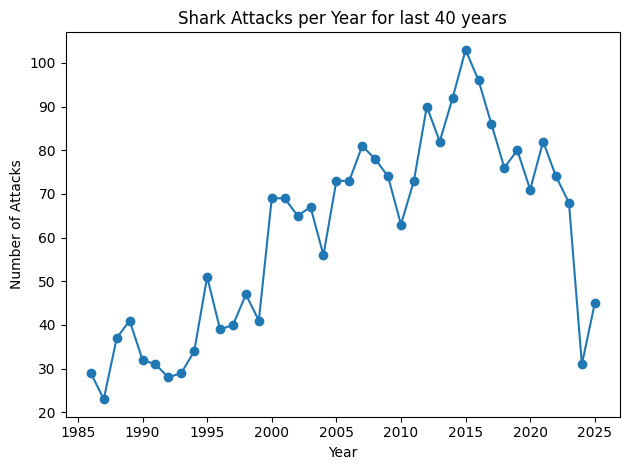

In [88]:
# Exclude 2026
filtered_data = df_final[df_final["year"] != 2026]

attack_by_year = filtered_data.groupby("year").size().sort_index()
print(f"The Number of Attacks by Year :\n\n{attack_by_year.tail(10)}")

plt.title("Shark Attacks per Year for last 40 years")
plt.plot(attack_by_year.index, attack_by_year.values, marker='o')
plt.xlabel("Year")
plt.ylabel("Number of Attacks")

plt.tight_layout()
plt.show()


## Buisness Question 4

Understand which customers are most at risk
- Age distribution of incidents
- Gender-based patterns

age_group
10-19    554
20-29    467
30-39    310
40-49    218
50-59    162
0-9       83
60-69     78
70-79     16
80-89      2
dtype: int64


/tmp/ipykernel_19959/1373298900.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_grouped.index, y=age_grouped.values, palette="viridis")


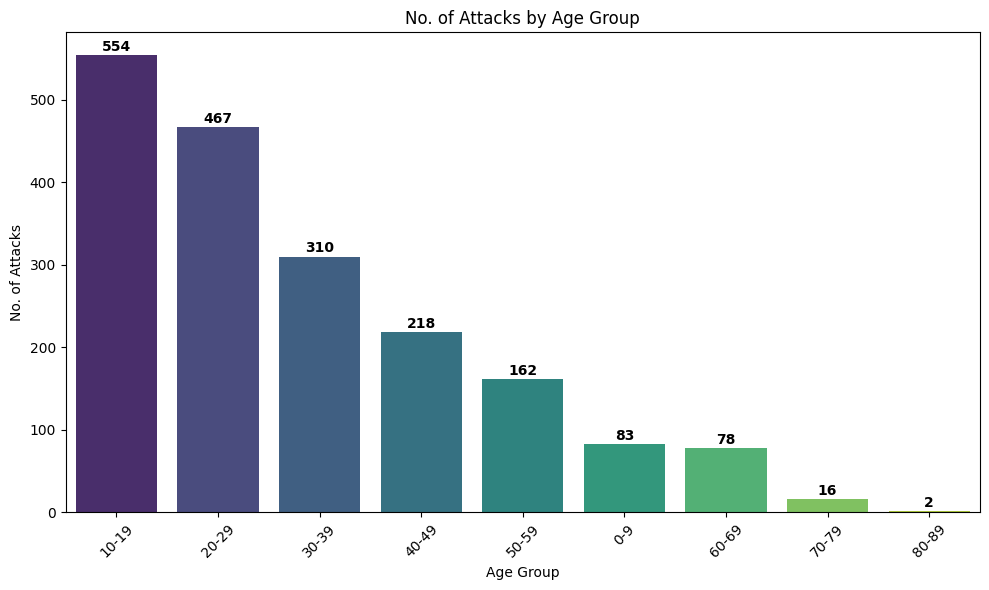

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

# Exclude 'Unknown' (case-insensitive)
filtered_df = df_final[~df_final["age_group"].str.lower().eq("unknown")]

# Group and sort
age_grouped = filtered_df.groupby("age_group").size().sort_values(ascending=False)

print(age_grouped)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x=age_grouped.index, y=age_grouped.values, palette="viridis")

# Add labels above bars
for i, v in enumerate(age_grouped.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.title("No. of Attacks by Age Group")
plt.xlabel("Age Group")
plt.ylabel("No. of Attacks")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

sex
Male      1921
Female     415
dtype: int64


/tmp/ipykernel_19959/1784530245.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sex_grouped.index, y=sex_grouped.values, palette="viridis")


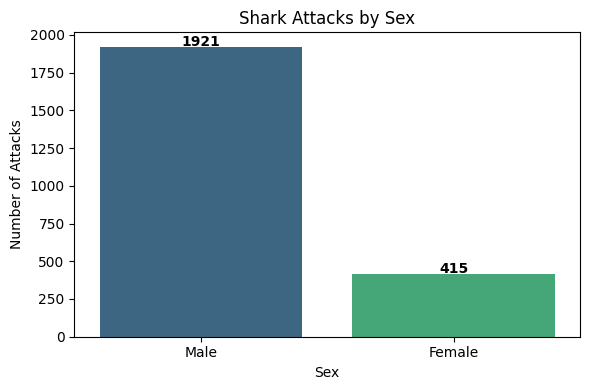

In [90]:
# Exclude the 'unknown' age group
filtered_df = df_final[df_final["sex"] != "Unknown"]

# Group by age_group and count
sex_grouped = filtered_df.groupby("sex").size().sort_values(ascending=False)

print(sex_grouped)

plt.figure(figsize=(6,4))
sns.barplot(x=sex_grouped.index, y=sex_grouped.values, palette="viridis")

# Add data labels
for i, v in enumerate(sex_grouped.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.title("Shark Attacks by Sex")
plt.xlabel("Sex")
plt.ylabel("Number of Attacks")

plt.tight_layout()
plt.show()


## Buisness Question 5

Examine which activities are too risky
- Attacks by activity
- Fatality rate per activity


Shark attacks by activity:
 activity_group
Surfing/Boardsports    944
Swimming               289
Fishing                203
In Water               180
Diving/Snorkeling      124
Name: count, dtype: int64


/tmp/ipykernel_19959/2659243143.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_19959/2659243143.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=activity_grouped.head(5).values, y=activity_grouped.head(5).index, palette="magma")


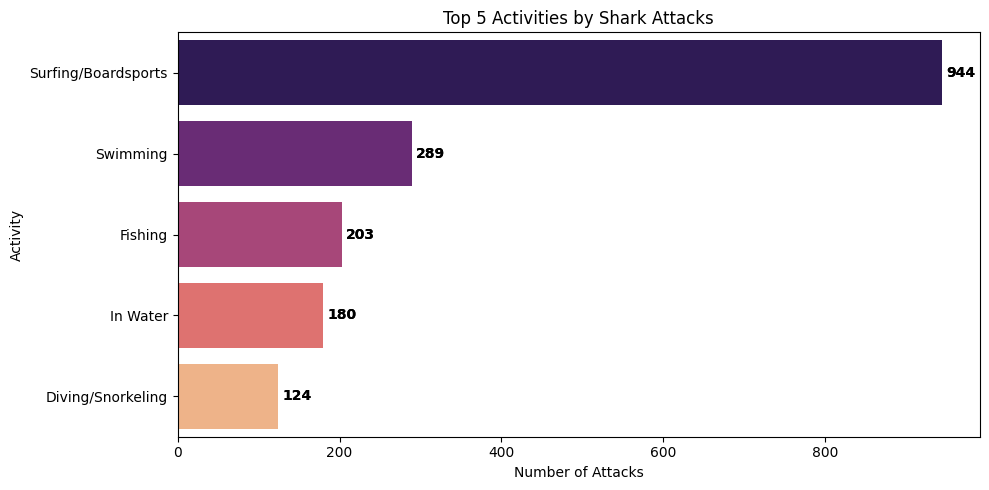

In [91]:
df_final = df_final[
    (df_final["activity_group"] != "Unknown") &
    (df_final["time_labels"] != "Unknown") &
    (df_final["activity_group"] != "Unknown")
]

activity_grouped = df_final["activity_group"].value_counts().head(5)
print("\nShark attacks by activity:\n", activity_grouped)



# Top 10 activities plot
plt.figure(figsize=(10,5))
ax = sns.barplot(
    x=activity_grouped.head(5).values,
    y=activity_grouped.head(5).index,
    palette="magma"
)
sns.barplot(x=activity_grouped.head(5).values, y=activity_grouped.head(5).index, palette="magma")
# 2. Add the labels
# padding=3 moves the text slightly to the right of the bar
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10, weight='bold')
plt.title("Top 5 Activities by Shark Attacks")
plt.xlabel("Number of Attacks")
plt.ylabel("Activity")
plt.tight_layout()
plt.show()




Top 5 Activities by Fatality Rate (%)

activity_group
Diving/Snorkeling      19.354839
Swimming               11.072664
Boating/Paddling        8.163265
Fishing                 7.389163
Surfing/Boardsports     6.144068
Name: fatal, dtype: float64


/tmp/ipykernel_19959/2748776890.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_19959/2748776890.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fatality_rate.head(5).values, y=fatality_rate.head(5).index, palette="Reds_r")


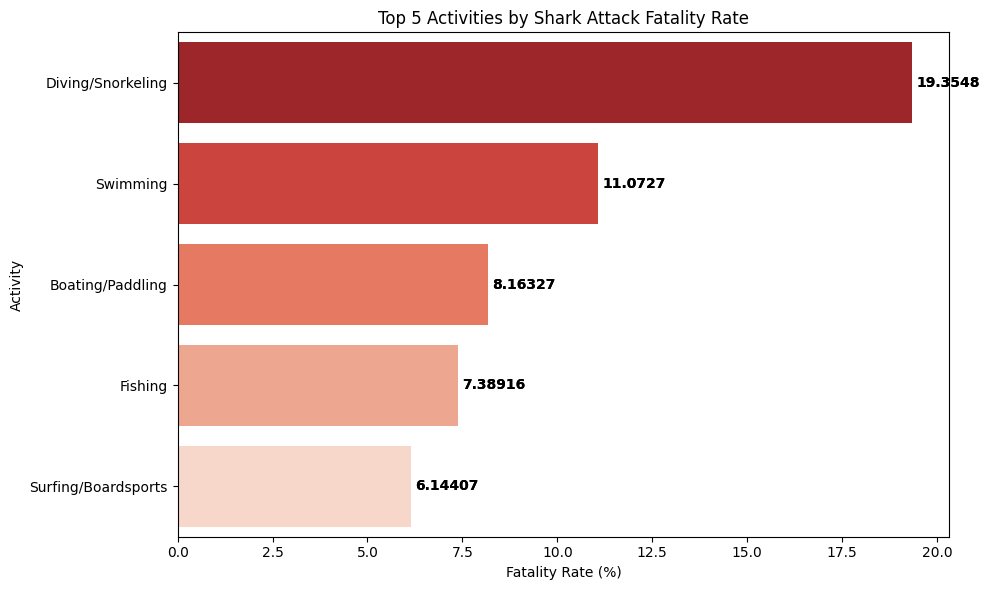

In [92]:

# Group by activity
activity_counts = df_final.groupby("activity_group")["fatal"].count()
fatal_counts = df_final.groupby("activity_group")["fatal"].apply(lambda x: (x == "Yes").sum())

# Calculate fatality rate (%)
fatality_rate = (fatal_counts / activity_counts * 100).sort_values(ascending=False)

# Display top 10 activities
print("Top 5 Activities by Fatality Rate (%)\n")
print(fatality_rate.head(5))

# Plot
plt.figure(figsize=(10,6))
ax = sns.barplot(
    x=fatality_rate.head(5).values,
    y=fatality_rate.head(5).index,
    palette="magma"
)
sns.barplot(x=fatality_rate.head(5).values, y=fatality_rate.head(5).index, palette="Reds_r")
plt.xlabel("Fatality Rate (%)")
plt.ylabel("Activity")
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10, weight='bold')
plt.title("Top 5 Activities by Shark Attack Fatality Rate")
plt.tight_layout()
plt.show()

##   Weighted risk score (0.4 × frequency + 0.6 × fatality)  for Activities:

In [105]:
#Step 1: Calculate frequency (%) from your data
activity_counts = df_final["activity_group"].value_counts()
activity_percent = round((activity_counts / activity_counts.sum()) * 100)

#Step 2: Calculate fatality rate (%) per activity
fatality_rate = df_final.groupby("activity_group")["fatal"].apply(
    lambda x: round((x == "Yes").mean() * 100)
)

#Step 3: Combine both
df_risk = pd.DataFrame({
    "Count": activity_counts,
    "frequency": activity_percent,
    "Fatality_Rate": fatality_rate
})

# Drop missing values (activities not in both)
df_risk = df_risk.dropna()

#Step 4: Calculate Risk Score
df_risk["Risk_Score"] = (
    0.4 * df_risk["frequency"] +
    0.6 * df_risk["Fatality_Rate"]
)


print(df_risk.sort_values(by="Risk_Score", ascending=False))


                     Count  frequency  Fatality_Rate  Risk_Score
activity_group                                                  
Surfing/Boardsports    944       52.0              6        24.4
Diving/Snorkeling      124        7.0             19        14.2
Swimming               289       16.0             11        13.0
Fishing                203       11.0              7         8.6
Boating/Paddling        49        3.0              8         6.0
In Water               180       10.0              2         5.2
Shark interaction       17        1.0              0         0.4
Other                    8        0.0              0         0.0


In [103]:
df_risk = df_risk.sort_values(by="Risk_Score", ascending=False)
df_risk

,Count,frequency,Fatality_Rate,Risk_Score
activity_group,,,,
Surfing/Boardsports,944,52.0,6,24.4
Diving/Snorkeling,124,7.0,19,14.2
Swimming,289,16.0,11,13.0
Fishing,203,11.0,7,8.6
Boating/Paddling,49,3.0,8,6.0
In Water,180,10.0,2,5.2
Shark interaction,17,1.0,0,0.4
Other,8,0.0,0,0.0
